# Dissimilaridade comportamental (Double-Fault) entre backbones (EfficientNet, ConvNeXt e Swin)

Este notebook mede a **diversidade comportamental** entre os backbones ja treinados
sobre o **conjunto de validacao do PANDAS** (fold 3, mesmo filtro de entropia de 20%
usado no treino). Sao considerados tres familias de arquiteturas:

- **EfficientNet** `b0`-`b7` — `models/family-b0.pth` … `models/family-b7.pth`
  (treinados por `efficientnet-family-optuna-ordinal-focal.ipynb`).
- **ConvNeXt** `tiny/small/base` — `models/convnext-family-{tiny,small,base}.pth`
  (treinados por `convnext-family-optuna-ordinal-focal.ipynb`).
- **Swin** `tiny/small/base` — `models/swin-family-{tiny,small,base}.pth`
  (treinados por `swin-family-optuna-ordinal-focal.ipynb`).

**Double-Fault measure (DF).** Para um par de classificadores *(i, j)*:

$$DF_{ij} = \frac{N^{11}_{ij}}{N} = P(\text{ambos erram a mesma amostra})$$

onde `N` e o numero de amostras de validacao e `N^{11}` o numero de amostras
classificadas **incorretamente pelos dois** modelos. Valores **altos** indicam
modelos que *falham juntos* (comportamento redundante / pouca diversidade);
valores **baixos** indicam modelos que erram em amostras diferentes
(comportamento complementar / alta diversidade). A diagonal `DF_{ii}` e a propria
taxa de erro do modelo *i*.

**t-SNE.** A matriz DF e convertida em uma matriz de **dissimilaridade**
(modelos que co-falham ficam *proximos*) e projetada em 2D com `t-SNE`
(`metric='precomputed'`) para visualizar o posicionamento de cada backbone.

> **Nota de compatibilidade.** Os checkpoints foram salvos por uma versao de
> `torch` >= 2.9 (formato com `.storage_alignment`). Caso o kernel use `torch`
> 2.8.x, o carregamento direto falha; este notebook inclui um leitor manual do
> zip do checkpoint que reconstroi o `state_dict` sem depender da versao do torch,
> e o re-salva em formato compativel (`models/<checkpoint>-t28.pth`).


In [1]:
import os
import sys
import gc
import io
import json
import zipfile
import pickle

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast
import torchvision.models as tvm

from sklearn.manifold import TSNE
from sklearn.metrics import cohen_kappa_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sys.path.append('../..')
from utils.dataset import PandasOverlapDataset

In [2]:
SEED              = 42
OUTPUT_CLASSES    = 5        # limiares ordinais para ISUP 0-5
VAL_FOLD          = 3        # mesmo fold de validacao usado no treino
ENTROPY_DROP_FRAC = 0.20     # mesmo filtro de ruido usado no treino
NUM_WORKERS       = 4
USE_AMP           = True

REPO_DIR   = '../..'
DATA_DIR   = os.path.join(REPO_DIR, 'data')
IMAGES_DIR = os.path.join(f"{REPO_DIR}/..", 'overlap')

MODEL_DIR  = 'models'
LOG_DIR    = 'logs'
os.makedirs(LOG_DIR, exist_ok=True)

# Registro unico de todos os backbones avaliados.
#   display_name : (arch, variant, checkpoint, short_label, batch_size)
# arch/variant selecionam o wrapper + constutor torchvision (ver secao 1);
# checkpoint e o arquivo em models/; short_label rotula o ponto no t-SNE;
# batch_size e o batch de inferencia (nets maiores recebem batch menor p/ caber na VRAM).
MODEL_REGISTRY = {
    'b0':             ('efficientnet', 'b0',    'family-b0.pth',            'B0',   8),
    'b1':             ('efficientnet', 'b1',    'family-b1.pth',            'B1',   8),
    'b2':             ('efficientnet', 'b2',    'family-b2.pth',            'B2',   8),
    'b3':             ('efficientnet', 'b3',    'family-b3.pth',            'B3',   4),
    'b4':             ('efficientnet', 'b4',    'family-b4.pth',            'B4',   4),
    'b5':             ('efficientnet', 'b5',    'family-b5.pth',            'B5',   2),
    'b6':             ('efficientnet', 'b6',    'family-b6.pth',            'B6',   2),
    'b7':             ('efficientnet', 'b7',    'family-b7.pth',            'B7',   2),
    'convnext-tiny':  ('convnext',     'tiny',  'convnext-family-tiny.pth',  'CN-T', 4),
    'convnext-small': ('convnext',     'small', 'convnext-family-small.pth', 'CN-S', 2),
    'convnext-base':  ('convnext',     'base',  'convnext-family-base.pth',  'CN-B', 2),
    'swin-tiny':      ('swin',         'tiny',  'swin-family-tiny.pth',      'SW-T', 4),
    'swin-small':     ('swin',         'small', 'swin-family-small.pth',     'SW-S', 2),
    'swin-base':      ('swin',         'base',  'swin-family-base.pth',      'SW-B', 2),
}

MODELS_TO_RUN = list(MODEL_REGISTRY)
BATCH_SIZE    = {n: spec[4] for n, spec in MODEL_REGISTRY.items()}
SHORT_LABEL   = {n: spec[3] for n, spec in MODEL_REGISTRY.items()}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device: {device}')
print(f'torch:  {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU:    {torch.cuda.get_device_name(0)}')
print(f'Modelos: {MODELS_TO_RUN}')


Device: cuda
torch:  2.8.0+cu128
GPU:    NVIDIA GeForce RTX 3060
Modelos: ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'convnext-tiny', 'convnext-small', 'convnext-base', 'swin-tiny', 'swin-small', 'swin-base']


## 1. Arquitetura e carregamento robusto dos pesos

Reconstruimos os wrappers dos tres notebooks de treino — `EfficientNetApi`,
`ConvNeXtApi` e `SwinApi`. Os checkpoints sao `state_dict`s puros;
`dropout_rate`/`unfreeze_blocks` so afetam treino (nao a forma dos tensores),
entao carregamos com valores padrao e `strict=True`.

`load_state_dict_any` tenta `torch.load`; se o checkpoint estiver no formato de
torch >= 2.9 e o kernel for mais antigo, cai num leitor manual do zip.


In [3]:
EFFICIENTNET_REGISTRY = {
    'b0': (tvm.efficientnet_b0, tvm.EfficientNet_B0_Weights.DEFAULT),
    'b1': (tvm.efficientnet_b1, tvm.EfficientNet_B1_Weights.DEFAULT),
    'b2': (tvm.efficientnet_b2, tvm.EfficientNet_B2_Weights.DEFAULT),
    'b3': (tvm.efficientnet_b3, tvm.EfficientNet_B3_Weights.DEFAULT),
    'b4': (tvm.efficientnet_b4, tvm.EfficientNet_B4_Weights.DEFAULT),
    'b5': (tvm.efficientnet_b5, tvm.EfficientNet_B5_Weights.DEFAULT),
    'b6': (tvm.efficientnet_b6, tvm.EfficientNet_B6_Weights.DEFAULT),
    'b7': (tvm.efficientnet_b7, tvm.EfficientNet_B7_Weights.DEFAULT),
}

CONVNEXT_REGISTRY = {
    'tiny':  (tvm.convnext_tiny,  tvm.ConvNeXt_Tiny_Weights.DEFAULT),
    'small': (tvm.convnext_small, tvm.ConvNeXt_Small_Weights.DEFAULT),
    'base':  (tvm.convnext_base,  tvm.ConvNeXt_Base_Weights.DEFAULT),
    'large': (tvm.convnext_large, tvm.ConvNeXt_Large_Weights.DEFAULT),
}

SWIN_REGISTRY = {
    'tiny':  (tvm.swin_t, tvm.Swin_T_Weights.DEFAULT),
    'small': (tvm.swin_s, tvm.Swin_S_Weights.DEFAULT),
    'base':  (tvm.swin_b, tvm.Swin_B_Weights.DEFAULT),
}


class EfficientNetApi(nn.Module):
    """Wrapper EfficientNet (b0-b7) com cabeca de regressao ordinal — identico ao treino."""

    def __init__(self, model, output_dimensions, dropout_rate=0.4, unfreeze_blocks=2):
        super().__init__()
        self.model = model

        for p in self.model.parameters():
            p.requires_grad = False
        if unfreeze_blocks > 0:
            for block in self.model.features[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        if isinstance(self.model.classifier, nn.Sequential):
            in_features = self.model.classifier[-1].in_features
        else:
            in_features = self.model.classifier.in_features
        self.model.classifier = nn.Identity()

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, output_dimensions),
        )

    def extract(self, x):
        x = self.model(x)
        if x.ndim == 4:
            x = x.mean(dim=[2, 3])
        return x

    def forward(self, x):
        return self.head(self.extract(x))


class ConvNeXtApi(nn.Module):
    """Wrapper ConvNeXt (tiny/small/base) — identico ao treino
    (convnext-family-optuna-ordinal-focal.ipynb)."""

    def __init__(self, model, output_dimensions, dropout_rate=0.4, unfreeze_blocks=2):
        super().__init__()
        self.model = model

        for p in self.model.parameters():
            p.requires_grad = False
        if unfreeze_blocks > 0:
            for block in self.model.features[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        if isinstance(self.model.classifier, nn.Sequential):
            in_features = self.model.classifier[-1].in_features
        else:
            in_features = self.model.classifier.in_features
        self.model.classifier = nn.Identity()

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, output_dimensions),
        )

    def extract(self, x):
        x = self.model(x)
        if x.ndim == 4:
            x = x.mean(dim=[2, 3])
        return x

    def forward(self, x):
        return self.head(self.extract(x))


class SwinApi(nn.Module):
    """Wrapper Swin Transformer (tiny/small/base) — identico ao treino
    (swin-family-optuna-ordinal-focal.ipynb). Diferente de EfficientNet/ConvNeXt,
    o Swin nao tem `classifier`: `head` (nn.Linear) e `norm` sao trocados por
    Identity e a normalizacao passa para a cabeca ordinal."""

    def __init__(self, model, output_dimensions, dropout_rate=0.4, unfreeze_blocks=2):
        super().__init__()
        self.model = model

        for p in self.model.parameters():
            p.requires_grad = False
        if unfreeze_blocks > 0:
            for block in self.model.features[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        if isinstance(self.model.head, nn.Sequential):
            in_features = self.model.head[-1].in_features
        else:
            in_features = self.model.head.in_features
        self.model.head = nn.Identity()
        self.model.norm = nn.Identity()  # a cabeca ordinal normaliza no lugar

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, output_dimensions),
        )

    def extract(self, x):
        x = self.model(x)
        if x.ndim == 4:
            x = x.mean(dim=[2, 3])
        return x

    def forward(self, x):
        return self.head(self.extract(x))


WRAPPER = {'efficientnet': EfficientNetApi, 'convnext': ConvNeXtApi, 'swin': SwinApi}
ARCH_REGISTRY = {'efficientnet': EFFICIENTNET_REGISTRY,
                 'convnext': CONVNEXT_REGISTRY,
                 'swin': SWIN_REGISTRY}


In [4]:
# ── leitor manual do checkpoint (independente da versao do torch) ──────────────
_STORAGE_DTYPE = {
    torch.FloatStorage: np.float32,  torch.DoubleStorage: np.float64,
    torch.HalfStorage:  np.float16,  torch.LongStorage:   np.int64,
    torch.IntStorage:   np.int32,    torch.ShortStorage:  np.int16,
    torch.CharStorage:  np.int8,     torch.ByteStorage:   np.uint8,
    torch.BoolStorage:  np.bool_,
}


def _manual_load_state_dict(path):
    """Le um checkpoint .pth (zip) tensor-a-tensor, sem depender da versao do torch."""
    zf   = zipfile.ZipFile(path)
    root = zf.namelist()[0].split('/')[0]
    try:
        byteorder = zf.read(f'{root}/byteorder').decode().strip()
    except KeyError:
        byteorder = 'little'

    class _Ph:                       # placeholder de storage
        def __init__(self, dtype, key):
            self.dtype, self.key = dtype, key

    def _persistent_load(pid):
        assert pid[0] == 'storage', pid
        storage_type, key = pid[1], pid[2]
        return _Ph(_STORAGE_DTYPE[storage_type], str(key))

    def _rebuild(storage, storage_offset, size, stride, requires_grad=False, *rest):
        arr = np.frombuffer(zf.read(f'{root}/data/{storage.key}'), dtype=storage.dtype).copy()
        if byteorder == 'big':
            arr = arr.byteswap()
        return torch.as_strided(torch.from_numpy(arr), tuple(size), tuple(stride), storage_offset)

    class _Unpickler(pickle.Unpickler):
        def persistent_load(self, pid):
            return _persistent_load(pid)

        def find_class(self, module, name):
            if module == 'torch._utils' and name == '_rebuild_tensor_v2':
                return _rebuild
            return super().find_class(module, name)

    return _Unpickler(io.BytesIO(zf.read(f'{root}/data.pkl'))).load()


def load_state_dict_any(ckpt_name):
    """Carrega o state_dict do checkpoint `ckpt_name`; usa cache -t28 ou converte se preciso."""
    stem = ckpt_name[:-4] if ckpt_name.endswith('.pth') else ckpt_name
    t28  = os.path.join(MODEL_DIR, f'{stem}-t28.pth')
    orig = os.path.join(MODEL_DIR, ckpt_name)
    if os.path.exists(t28):
        return torch.load(t28, map_location=device, weights_only=True)
    try:
        return torch.load(orig, map_location=device, weights_only=True)
    except RuntimeError as e:
        if 'storage_alignment' not in str(e) and 'subdirectory' not in str(e):
            raise
        print(f'  [{ckpt_name}] torch.load falhou (checkpoint torch>=2.9); usando leitor manual + cache')
        sd = _manual_load_state_dict(orig)
        torch.save(sd, t28)               # cache em formato compativel com o kernel atual
        return sd


def load_model(name):
    """Instancia o wrapper correto (EfficientNet/ConvNeXt/Swin) e carrega os pesos."""
    arch, variant, ckpt = MODEL_REGISTRY[name][:3]
    ctor, weights = ARCH_REGISTRY[arch][variant]
    model = WRAPPER[arch](ctor(weights=weights), OUTPUT_CLASSES).to(device)
    model.load_state_dict(load_state_dict_any(ckpt))
    model.eval()
    return model


def decode_ordinal_predictions(logits):
    """sigmoid -> threshold @ 0.5 -> soma  ==>  grau ISUP 0..5."""
    return (torch.sigmoid(logits.float()) > 0.5).sum(dim=1)


def free_vram(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 2. Conjunto de validacao do PANDAS

Reproduz exatamente a divisao usada no treino: filtro de entropia (20% mais ruidosas removidas), fold 3 como validacao, e remocao de imagens ausentes em disco.

In [5]:
df_all = pd.read_csv(os.path.join(DATA_DIR, 'train_5fold.csv'))
df_all.columns = df_all.columns.str.strip()

# filtro de ruido (identico ao treino)
df_entropy = pd.read_csv(os.path.join(DATA_DIR, 'entropy.csv'))
df_entropy = df_entropy.sort_values('difficulty_score', ascending=False)
n_remove   = int(len(df_entropy) * ENTROPY_DROP_FRAC)
noisy_ids  = set(df_entropy.head(n_remove)['image_id'])
df_all     = df_all[~df_all['image_id'].isin(noisy_ids)].reset_index(drop=True)


def drop_missing(df):
    exists = df['image_id'].apply(lambda x: os.path.isdir(os.path.join(IMAGES_DIR, str(x))))
    return df[exists].reset_index(drop=True)


df_val = drop_missing(df_all[df_all['fold'] == VAL_FOLD].reset_index(drop=True))
print(f'Amostras de validacao: {len(df_val)}')
print('Distribuicao por classe ISUP:')
print(df_val['isup_grade'].value_counts().sort_index())

# ordem canonica das amostras (todas as predicoes serao alinhadas a esta ordem)
VAL_IMAGE_IDS = df_val['image_id'].str.strip().tolist()

Amostras de validacao: 1182
Distribuicao por classe ISUP:
isup_grade
0    347
1    294
2    151
3    140
4    129
5    121
Name: count, dtype: int64


In [6]:
def make_val_loader(batch_size):
    val_ds = PandasOverlapDataset(IMAGES_DIR, df_val, transforms=None, overlap=0)
    return DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )

## 3. Inferencia de cada modelo sobre a validacao

Cada backbone gera um vetor de predicoes (grau ISUP 0–5) **alinhado** a mesma ordem de amostras. Guardamos tambem o vetor binario de erro (`1` = errou, `0` = acertou), base do double-fault.

In [7]:
@torch.no_grad()
def predict(model, name):
    loader = make_val_loader(BATCH_SIZE[name])
    preds, probs, img_ids = [], [], []
    for imgs, _, ids in tqdm(loader, desc=f'Infer {name}', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        with autocast(device_type='cuda', enabled=(USE_AMP and torch.cuda.is_available()),
                      dtype=torch.float16):
            logits = model(imgs)
        p = torch.sigmoid(logits.float()).cpu()              # (B, OUTPUT_CLASSES)
        probs.append(p)
        preds.append((p > 0.5).sum(dim=1))                   # == decode_ordinal_predictions
        img_ids.extend([i.strip() for i in ids])
    return torch.cat(preds).numpy().astype(int), torch.cat(probs).numpy(), img_ids


# ground-truth na ordem canonica
gts = df_val['isup_grade'].to_numpy().astype(int)

pred_matrix = {}   # name -> vetor de predicoes (N,)
proba_val   = {}   # name -> probabilidades ordinais (N, OUTPUT_CLASSES) — usadas no stacking/boosting
for name in MODELS_TO_RUN:
    print(f'>>> {name}')
    model = load_model(name)
    preds, probs, img_ids = predict(model, name)
    assert img_ids == VAL_IMAGE_IDS, f'desalinhamento de amostras em {name}'
    pred_matrix[name] = preds
    proba_val[name]   = probs
    free_vram(model)

print('\nInferencia concluida para:', list(pred_matrix.keys()))

>>> b0


Infer b0:   0%|          | 0/148 [00:00<?, ?it/s]

>>> b1


Infer b1:   0%|          | 0/148 [00:00<?, ?it/s]

>>> b2


...

Infer swin-small:   0%|          | 0/591 [00:00<?, ?it/s]

>>> swin-base
Downloading: "https://download.pytorch.org/models/swin_b-68c6b09e.pth" to /home/woshington/.cache/torch/hub/checkpoints/swin_b-68c6b09e.pth


100%|██████████| 335M/335M [00:04<00:00, 85.8MB/s] 


Infer swin-base:   0%|          | 0/591 [00:00<?, ?it/s]


Inferencia concluida para: ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'convnext-tiny', 'convnext-small', 'convnext-base', 'swin-tiny', 'swin-small', 'swin-base']


In [8]:
# DataFrame de predicoes (uma coluna por modelo) + ground-truth, salvo para reuso
pred_df = pd.DataFrame({'image_id': VAL_IMAGE_IDS, 'isup_grade': gts})
for name in MODELS_TO_RUN:
    pred_df[name] = pred_matrix[name]
pred_csv = os.path.join(LOG_DIR, 'family-double-fault-predictions.csv')
pred_df.to_csv(pred_csv, index=False)
print('Salvo:', pred_csv)
pred_df.head()

Salvo: logs/family-double-fault-predictions.csv


,image_id,isup_grade,b0,b1,b2,b3,b4,b5,b6,b7,convnext-tiny,convnext-small,convnext-base,swin-tiny,swin-small,swin-base
0,34a98ca2d4eb1a91e428bf2112e26543,1,0,1,0,1,0,0,1,1,0,0,1,0,0,0
1,a197f9bef5596491c736c23a58bbf414,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,21842d9a9ebb1e4efb6527fa04163452,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1
3,2b4e8eac6e778eddf0fe5b64e7ab47a8,3,3,3,3,4,3,3,3,3,3,3,3,3,2,3
4,5289d3ebfc24bbe70206daf1f546b687,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4. Desempenho individual (referencia)

QWK / acuracia de cada modelo na validacao — usados depois para colorir o t-SNE.

In [9]:
P = np.vstack([pred_matrix[n] for n in MODELS_TO_RUN])   # (M, N)
M, N = P.shape
ERR  = (P != gts[None, :]).astype(int)                   # matriz de erro (M, N): 1 = errou

perf = pd.DataFrame({
    'model':      MODELS_TO_RUN,
    'qwk':        [cohen_kappa_score(gts, pred_matrix[n], weights='quadratic') for n in MODELS_TO_RUN],
    'accuracy':   [accuracy_score(gts, pred_matrix[n]) for n in MODELS_TO_RUN],
    'error_rate': ERR.mean(axis=1),
})
perf

,model,qwk,accuracy,error_rate
0,b0,0.893948,0.749577,0.250423
1,b1,0.898861,0.730964,0.269036
2,b2,0.887881,0.736041,0.263959
3,b3,0.892013,0.712352,0.287648
4,b4,0.881705,0.695431,0.304569
5,b5,0.867278,0.658206,0.341794
6,b6,0.874344,0.656514,0.343486
7,b7,0.863086,0.645516,0.354484
8,convnext-tiny,0.885215,0.695431,0.304569
9,convnext-small,0.818667,0.609983,0.390017


## 5. Matriz Double-Fault (dissimilaridade comportamental)

$DF_{ij}$ = fracao de amostras erradas por **ambos** os modelos. Diagonal = taxa de erro individual.

Matriz Double-Fault (linha/coluna = modelo):


,b0,b1,b2,b3,b4,b5,b6,b7,convnext-tiny,convnext-small,convnext-base,swin-tiny,swin-small,swin-base
b0,0.2504,0.1675,0.1582,0.1684,0.1675,0.1692,0.1734,0.1717,0.1641,0.1760,0.1472,0.1675,0.1827,0.1531
b1,0.1675,0.2690,0.1760,0.1810,0.1743,0.1734,0.1734,0.1827,0.1658,0.1878,0.1658,0.1810,0.1912,0.1726
b2,0.1582,0.1760,0.2640,0.1751,0.1667,0.1734,0.1810,0.1734,0.1675,0.1819,0.1591,0.1827,0.1937,0.1675
b3,0.1684,0.1810,0.1751,0.2876,0.1895,0.1895,0.1954,0.2014,0.1827,0.2081,0.1743,0.1861,0.2200,0.1827
b4,0.1675,0.1743,0.1667,0.1895,0.3046,0.2047,0.2157,0.2310,0.2014,0.2259,0.2064,0.2064,0.2318,0.2030
b5,0.1692,0.1734,0.1734,0.1895,0.2047,0.3418,0.2208,0.2327,0.1980,0.2225,0.2030,0.2081,0.2293,0.1954
b6,0.1734,0.1734,0.1810,0.1954,0.2157,0.2208,0.3435,0.2445,0.2081,0.2386,0.2005,0.2174,0.2462,0.2107
b7,0.1717,0.1827,0.1734,0.2014,0.2310,0.2327,0.2445,0.3545,0.2064,0.2453,0.2081,0.2183,0.2614,0.2124
convnext-tiny,0.1641,0.1658,0.1675,0.1827,0.2014,0.1980,0.2081,0.2064,0.3046,0.2140,0.2149,0.2115,0.2301,0.2107
convnext-small,0.1760,0.1878,0.1819,0.2081,0.2259,0.2225,0.2386,0.2453,0.2140,0.3900,0.2090,0.2327,0.3164,0.2343


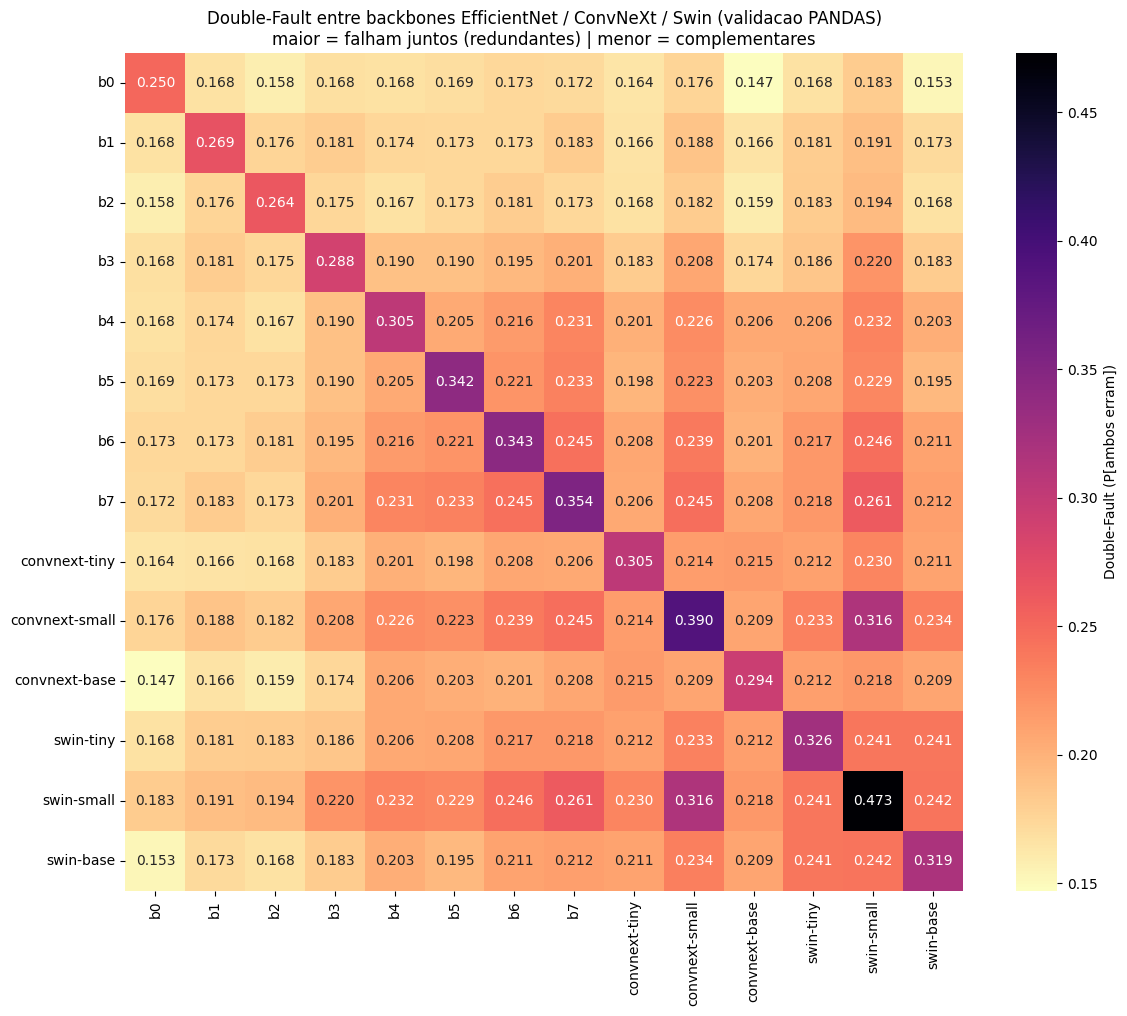

In [10]:
# DF_ij = (1/N) * sum_n [erro_i(n) AND erro_j(n)]
DF = (ERR @ ERR.T) / N        # (M, M), simetrica; diagonal = taxa de erro

df_matrix = pd.DataFrame(DF, index=MODELS_TO_RUN, columns=MODELS_TO_RUN)
df_matrix.to_csv(os.path.join(LOG_DIR, 'family-double-fault-matrix.csv'))
print('Matriz Double-Fault (linha/coluna = modelo):')
display(df_matrix.round(4))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_matrix, annot=True, fmt='.3f', cmap='magma_r', square=True,
            cbar_kws={'label': 'Double-Fault (P[ambos erram])'}, ax=ax)
ax.set_title('Double-Fault entre backbones EfficientNet / ConvNeXt / Swin (validacao PANDAS)\n'
             'maior = falham juntos (redundantes) | menor = complementares')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-double-fault-matrix.png'), dpi=200, bbox_inches='tight')
plt.show()


## 6. Projecao 2D dos modelos com t-SNE

Convertendo o double-fault (similaridade de co-falha) em **dissimilaridade**:

$$D_{ij} = \max_{a\neq b}(DF_{ab}) - DF_{ij} \quad (i\neq j), \qquad D_{ii}=0$$

Assim, modelos que **falham juntos** (DF alto) ficam **proximos** no mapa, e
modelos com comportamento de erro complementar ficam afastados. Com poucos pontos, usamos `perplexity=3` e `metric='precomputed'`.


In [11]:
# matriz de dissimilaridade a partir do double-fault (off-diagonal), diagonal zerada
off = DF.copy()
np.fill_diagonal(off, np.nan)
dmax = np.nanmax(off)
D = dmax - DF
np.fill_diagonal(D, 0.0)
D = (D + D.T) / 2            # garante simetria numerica

tsne = TSNE(
    n_components=2,
    metric='precomputed',
    init='random',
    perplexity=3,
    learning_rate='auto',
    random_state=SEED,
)
emb = tsne.fit_transform(D)   # (M, 2)
print('Embedding t-SNE:\n', np.round(emb, 3))

Embedding t-SNE:
 [[ -9.535 102.256]
 [ 14.567 -78.447]
 [ 56.339 -36.132]
 [ -7.434 -33.002]
 [-55.956  51.061]
 [-60.304 -36.358]
 [-76.37    7.335]
 [-41.328   1.647]
 [ -3.347  43.383]
 [ 15.852  -1.378]
 [ 33.254  51.722]
 [ 74.536  15.592]
 [ -2.612   9.474]
 [ 93.237  36.024]]


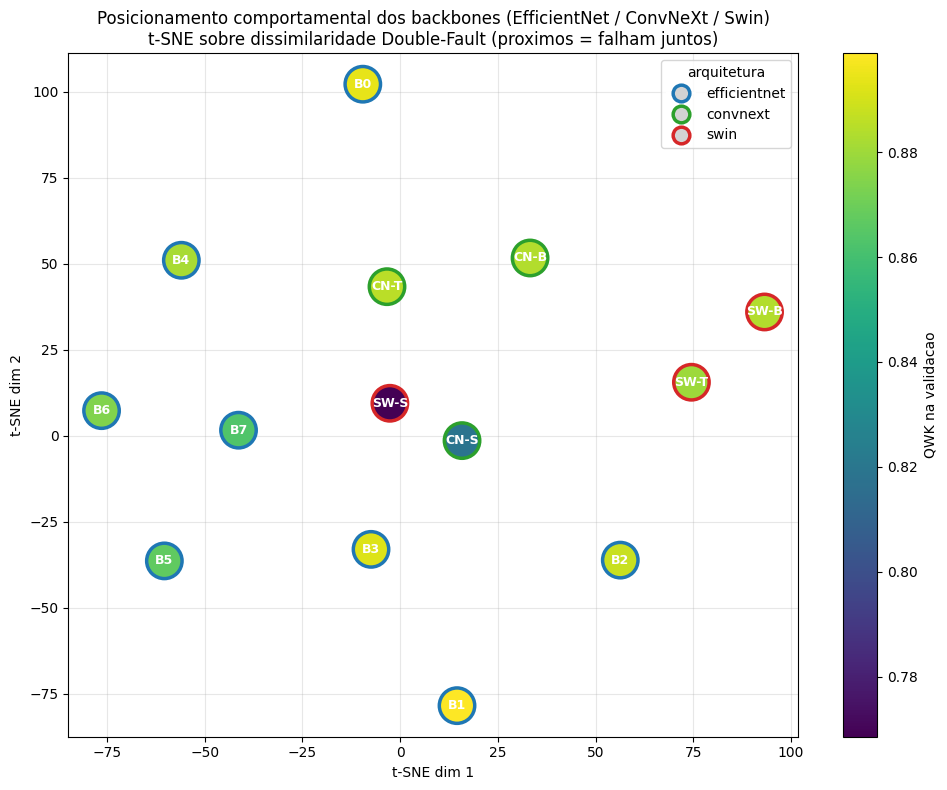

Artefatos salvos em logs/:
  - family-double-fault-predictions.csv
  - family-double-fault-matrix.csv / .png
  - family-double-fault-tsne.png


In [12]:
qwk_vals = perf['qwk'].to_numpy()

# cor do marcador por familia de arquitetura (contorno), preenchido por QWK
ARCH_EDGE = {'efficientnet': '#1f77b4', 'convnext': '#2ca02c', 'swin': '#d62728'}
edge_colors = [ARCH_EDGE[MODEL_REGISTRY[n][0]] for n in MODELS_TO_RUN]

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(emb[:, 0], emb[:, 1], c=qwk_vals, s=650,
                cmap='viridis', edgecolors=edge_colors, linewidths=2.5, zorder=3)

for i, name in enumerate(MODELS_TO_RUN):
    ax.annotate(SHORT_LABEL[name], (emb[i, 0], emb[i, 1]),
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='white', zorder=4)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('QWK na validacao')

# legenda das familias (cor do contorno)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
                  markeredgecolor=c, markeredgewidth=2.5, markersize=12, label=a)
           for a, c in ARCH_EDGE.items()]
ax.legend(handles=handles, title='arquitetura', loc='best')

ax.set_title('Posicionamento comportamental dos backbones (EfficientNet / ConvNeXt / Swin)\n'
             't-SNE sobre dissimilaridade Double-Fault (proximos = falham juntos)')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-double-fault-tsne.png'), dpi=200, bbox_inches='tight')
plt.show()

print('Artefatos salvos em logs/:')
print('  - family-double-fault-predictions.csv')
print('  - family-double-fault-matrix.csv / .png')
print('  - family-double-fault-tsne.png')


## 7. Avaliacao individual no conjunto de TESTE (`data/test.csv`)

Aqui cada um dos 8 backbones (`b0`-`b7`) e avaliado no **conjunto de teste
independente** do PANDAS (`data/test.csv`), sem qualquer filtro de entropia
(o filtro de ruido so vale para treino/validacao). Para cada modelo guardamos as
**probabilidades ordinais por limiar** (`sigmoid(logits)`, shape `(N, 5)`), que
servem tanto para decodificar a predicao individual (`>0.5 -> soma -> ISUP 0..5`)
quanto para construir o ensemble por media de probabilidades (secao 8).

Metricas reportadas por modelo: **QWK** (kappa quadratico), **acuracia** e
**F1 macro**.

In [13]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# conjunto de teste independente — avaliado integralmente (sem filtro de entropia)
df_test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
df_test.columns = df_test.columns.str.strip()
df_test = drop_missing(df_test.reset_index(drop=True))

TEST_IMAGE_IDS = df_test['image_id'].str.strip().tolist()
gts_test = df_test['isup_grade'].to_numpy().astype(int)

print(f'Amostras de teste: {len(df_test)}')
print('Distribuicao por classe ISUP:')
print(df_test['isup_grade'].value_counts().sort_index())

Amostras de teste: 1061
Distribuicao por classe ISUP:
isup_grade
0    300
1    251
2    143
3    122
4    115
5    130
Name: count, dtype: int64


In [14]:
def make_loader(df, batch_size):
    ds = PandasOverlapDataset(IMAGES_DIR, df, transforms=None, overlap=0)
    return DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )


@torch.no_grad()
def predict_proba(model, name, df):
    """Retorna (probs, img_ids): probs = sigmoid(logits) com shape (N, OUTPUT_CLASSES)."""
    loader = make_loader(df, BATCH_SIZE[name])
    probs, img_ids = [], []
    for imgs, _, ids in tqdm(loader, desc=f'Test {name}', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        with autocast(device_type='cuda', enabled=(USE_AMP and torch.cuda.is_available()),
                      dtype=torch.float16):
            logits = model(imgs)
        probs.append(torch.sigmoid(logits.float()).cpu())
        img_ids.extend([i.strip() for i in ids])
    return torch.cat(probs).numpy(), img_ids


def preds_from_proba(probs):
    """probs (N, 5) -> grau ISUP 0..5 (threshold @ 0.5, soma dos limiares)."""
    return (probs > 0.5).sum(axis=1).astype(int)

In [15]:
# inferencia de cada backbone no conjunto de teste (probabilidades ordinais)
proba_test = {}   # name -> probs (N, OUTPUT_CLASSES)
for name in MODELS_TO_RUN:
    print(f'>>> {name}')
    model = load_model(name)
    probs, ids = predict_proba(model, name, df_test)
    assert ids == TEST_IMAGE_IDS, f'desalinhamento de amostras de teste em {name}'
    proba_test[name] = probs
    free_vram(model)

print('\nInferencia de teste concluida para:', list(proba_test.keys()))

>>> b0


Test b0:   0%|          | 0/133 [00:00<?, ?it/s]

>>> b1


Test b1:   0%|          | 0/133 [00:00<?, ?it/s]

>>> b2


...

>>> swin-small


Test swin-small:   0%|          | 0/531 [00:00<?, ?it/s]

>>> swin-base


Test swin-base:   0%|          | 0/531 [00:00<?, ?it/s]


Inferencia de teste concluida para: ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'convnext-tiny', 'convnext-small', 'convnext-base', 'swin-tiny', 'swin-small', 'swin-base']


In [16]:
# metricas individuais no teste + tabela de predicoes
LABELS = [f'ISUP {i}' for i in range(6)]


def eval_preds(preds, gts):
    return dict(
        qwk=cohen_kappa_score(gts, preds, weights='quadratic'),
        accuracy=accuracy_score(gts, preds),
        macro_f1=f1_score(gts, preds, average='macro'),
    )


pred_test_matrix = {n: preds_from_proba(proba_test[n]) for n in MODELS_TO_RUN}

rows = []
for n in MODELS_TO_RUN:
    m = eval_preds(pred_test_matrix[n], gts_test)
    rows.append({'model': n.upper(), **m})
perf_test = pd.DataFrame(rows)

perf_test.to_csv(os.path.join(LOG_DIR, 'family-test-individual.csv'), index=False)
print('Salvo: logs/family-test-individual.csv')
display(perf_test.round(4))

# tabela de predicoes por amostra (uma coluna por modelo) + ground-truth
pred_test_df = pd.DataFrame({'image_id': TEST_IMAGE_IDS, 'isup_grade': gts_test})
for n in MODELS_TO_RUN:
    pred_test_df[n] = pred_test_matrix[n]
pred_test_df.to_csv(os.path.join(LOG_DIR, 'family-test-predictions.csv'), index=False)
print('Salvo: logs/family-test-predictions.csv')

Salvo: logs/family-test-individual.csv


,model,qwk,accuracy,macro_f1
0,B0,0.8798,0.7135,0.6678
1,B1,0.8916,0.7286,0.6828
2,B2,0.8705,0.7191,0.6774
3,B3,0.8500,0.6598,0.5995
4,B4,0.8535,0.6777,0.6106
5,B5,0.8370,0.6343,0.5875
6,B6,0.8458,0.6466,0.5909
7,B7,0.8348,0.6258,0.5730
8,CONVNEXT-TINY,0.8655,0.7003,0.6412
9,CONVNEXT-SMALL,0.7862,0.5636,0.5029


Salvo: logs/family-test-predictions.csv


## 8. Estrategias de ensemble dos backbones selecionados

Combinamos os backbones em `ENSEMBLE_MEMBERS` com **varias estrategias** e
comparamos todas com os modelos individuais no conjunto de teste. As estrategias
operam sobre as probabilidades ordinais `sigmoid(logits)` (`proba_test`, shape
`(N, 5)`) ou sobre as predicoes ja decodificadas (`pred_test_matrix`, ISUP 0..5):

**Soft (combinam probabilidades, depois decodificam `>0.5 -> soma`)**
- **mean** — media simples das probabilidades por limiar.
- **weighted_mean** — media ponderada pelo **QWK de validacao** de cada membro
  (pesos normalizados; sem usar o teste, evitando vazamento).
- **max** — maximo elemento-a-elemento das probabilidades.

**Hard (combinam predicoes ISUP discretas)**
- **majority_vote** — classe mais votada; empate desfeito pela **mediana** dos
  votos (coerente com a ordem ISUP).
- **weighted_vote** — voto majoritario ponderado pelo QWK de validacao.
- **median** — mediana das predicoes dos membros (robusta e ordinal).

**Meta-aprendizes (treinados na VALIDACAO, aplicados ao teste)**
- **boosting** — `GradientBoostingClassifier` (boosting de arvores) treinado
  sobre as probabilidades concatenadas dos membros como features (stacking com
  meta-modelo de boosting).
- **stacking_lr** — meta-modelo de **regressao logistica** sobre as mesmas
  features (stacking linear classico).

Para cada estrategia reportamos **QWK**, **acuracia** e **F1 macro**.

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# ENSEMBLE_MEMBERS = ['b1', 'convnext-tiny', 'swin-base']
ENSEMBLE_MEMBERS = ['b0', 'b1', "b2", 'b3', 'convnext-tiny', 'swin-base']
# ensemble multi-arquitetura (mistura EfficientNet + ConvNeXt + Swin):
# ENSEMBLE_MEMBERS = ['b3', 'b5', 'convnext-small', 'convnext-base', 'swin-small', 'swin-base']
ENS_TAG = '+'.join(ENSEMBLE_MEMBERS)

# pesos por desempenho na VALIDACAO (QWK normalizado) — nao usa o teste
val_qwk = perf.set_index('model').loc[ENSEMBLE_MEMBERS, 'qwk'].to_numpy()
WEIGHTS = val_qwk / val_qwk.sum()

P_test  = np.stack([proba_test[n] for n in ENSEMBLE_MEMBERS])         # (M, N, 5)
PRED_M  = np.vstack([pred_test_matrix[n] for n in ENSEMBLE_MEMBERS])  # (M, N) ISUP 0..5

# features de stacking: probabilidades concatenadas dos membros
X_val  = np.hstack([proba_val[n]  for n in ENSEMBLE_MEMBERS])         # (Nval,  M*5)
X_test = np.hstack([proba_test[n] for n in ENSEMBLE_MEMBERS])         # (Ntest, M*5)


def _vote(votes, w=None):
    """Voto (ponderado) por amostra; empate desfeito pela mediana dos votos."""
    M, N = votes.shape
    w = np.ones(M) if w is None else np.asarray(w)
    out = np.empty(N, dtype=int)
    for i in range(N):
        col = votes[:, i]
        tally = np.bincount(col, weights=w, minlength=6)
        top = tally.max()
        winners = np.where(np.isclose(tally, top))[0]
        out[i] = winners[0] if len(winners) == 1 else int(np.round(np.median(col)))
    return out


def _gb():
    clf = GradientBoostingClassifier(random_state=SEED)
    clf.fit(X_val, gts)                       # gts = ground-truth da VALIDACAO
    return clf.predict(X_test).astype(int)


def _lr():
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_val, gts)
    return clf.predict(X_test).astype(int)


STRATEGIES = {
    'mean':          lambda: preds_from_proba(P_test.mean(axis=0)),
    'weighted_mean': lambda: preds_from_proba(np.tensordot(WEIGHTS, P_test, axes=(0, 0))),
    'max':           lambda: preds_from_proba(P_test.max(axis=0)),
    'majority_vote': lambda: _vote(PRED_M),
    'weighted_vote': lambda: _vote(PRED_M, WEIGHTS),
    'median':        lambda: np.round(np.median(PRED_M, axis=0)).astype(int),
    'boosting':      _gb,
    'stacking_lr':   _lr,
}

print(f'Membros: {ENS_TAG}   pesos(QWK val) = '
      + ', '.join(f'{n}:{w:.3f}' for n, w in zip(ENSEMBLE_MEMBERS, WEIGHTS)) + '\n')

ens_results = {}
for sname, fn in STRATEGIES.items():
    preds = fn()
    ens_results[sname] = {'preds': preds, 'metrics': eval_preds(preds, gts_test)}
    m = ens_results[sname]['metrics']
    print(f"  {sname:14s}  QWK={m['qwk']:.4f}  Acc={m['accuracy']*100:5.2f}%  F1={m['macro_f1']:.4f}")

# tabela comparativa: 8 individuais + todas as estrategias de ensemble
comp = perf_test.copy()
ens_rows = pd.DataFrame([
    {'model': f'ENS-{s}({ENS_TAG})', **ens_results[s]['metrics']} for s in STRATEGIES
])
comp = pd.concat([comp, ens_rows], ignore_index=True)
comp.to_csv(os.path.join(LOG_DIR, 'family-test-ensemble-comparison.csv'), index=False)
display(comp.round(4))

Membros: b0+b1+b2+b3+convnext-tiny+swin-base   pesos(QWK val) = b0:0.167, b1:0.168, b2:0.166, b3:0.167, convnext-tiny:0.166, swin-base:0.165

  mean            QWK=0.8921  Acc=74.46%  F1=0.6995
  weighted_mean   QWK=0.8921  Acc=74.46%  F1=0.6995
  max             QWK=0.8451  Acc=63.43%  F1=0.5903
  majority_vote   QWK=0.8890  Acc=73.42%  F1=0.6851
  weighted_vote   QWK=0.8819  Acc=73.80%  F1=0.6908
  median          QWK=0.8909  Acc=72.48%  F1=0.6756
  boosting        QWK=0.8786  Acc=74.36%  F1=0.7051
  stacking_lr     QWK=0.8958  Acc=77.85%  F1=0.7435


,model,qwk,accuracy,macro_f1
0,B0,0.8798,0.7135,0.6678
1,B1,0.8916,0.7286,0.6828
2,B2,0.8705,0.7191,0.6774
3,B3,0.8500,0.6598,0.5995
4,B4,0.8535,0.6777,0.6106
5,B5,0.8370,0.6343,0.5875
6,B6,0.8458,0.6466,0.5909
7,B7,0.8348,0.6258,0.5730
8,CONVNEXT-TINY,0.8655,0.7003,0.6412
9,CONVNEXT-SMALL,0.7862,0.5636,0.5029


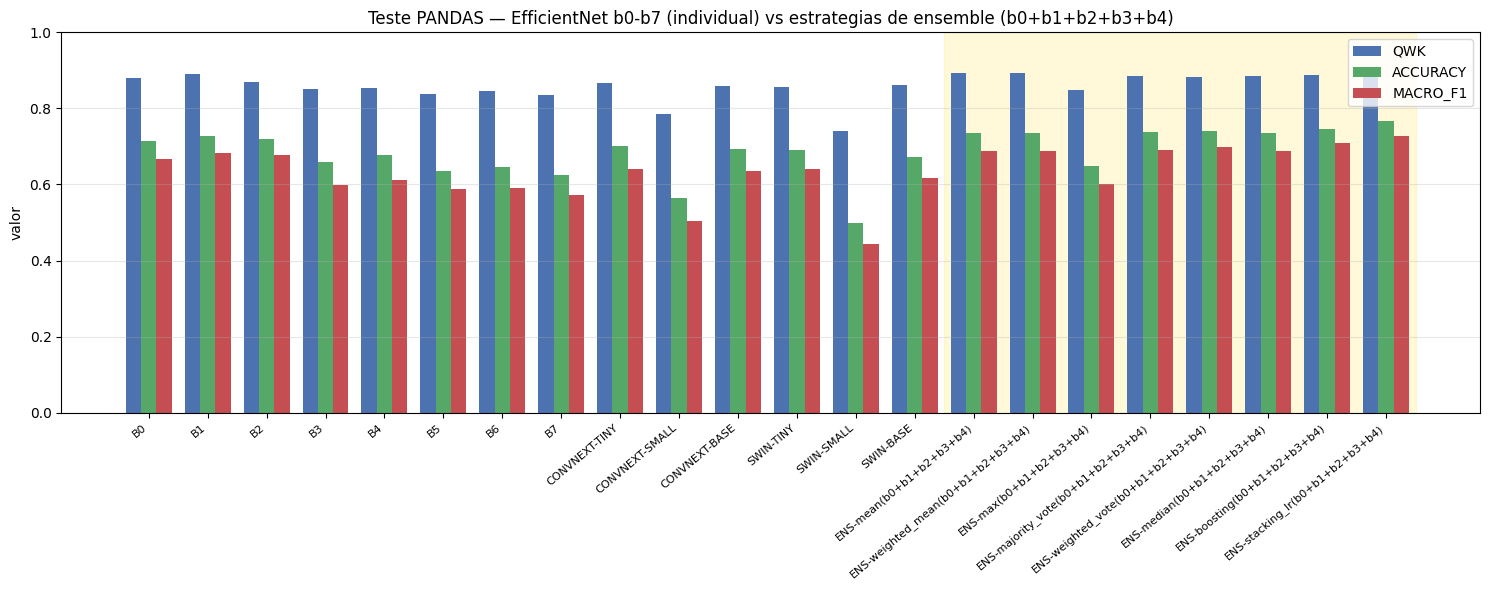

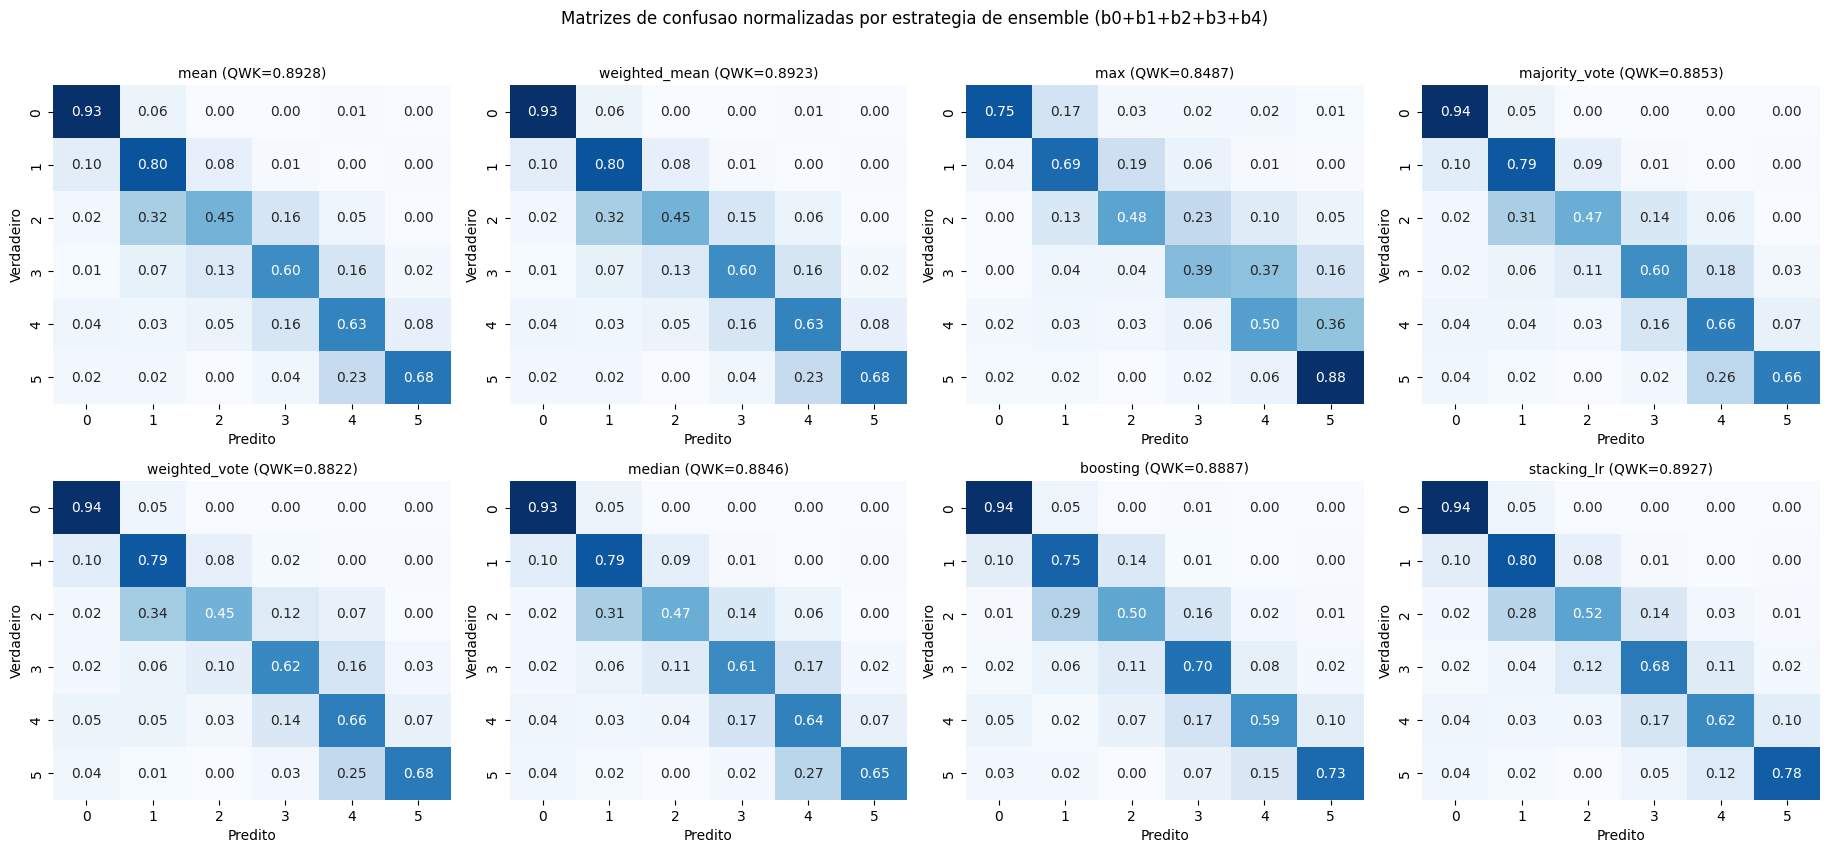

In [18]:
# (a) comparacao de QWK/Acc/F1: 8 individuais + todas as estrategias de ensemble
metrics_cols = ['qwk', 'accuracy', 'macro_f1']
x = np.arange(len(comp))
width = 0.26
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(15, 6))
for k, (col, c) in enumerate(zip(metrics_cols, colors)):
    ax.bar(x + (k - 1) * width, comp[col], width, label=col.upper(), color=c)
ax.set_xticks(x)
ax.set_xticklabels(comp['model'], rotation=40, ha='right', fontsize=8)
ax.set_ylim(0, 1.0)
ax.set_ylabel('valor')
ax.set_title(f'Teste PANDAS — EfficientNet b0-b7 (individual) vs estrategias de ensemble ({ENS_TAG})')
# destaca o bloco das estrategias de ensemble
ax.axvspan(len(perf_test) - 0.5, x[-1] + 0.5, color='gold', alpha=0.15, zorder=0)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-test-comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

# (b) matrizes de confusao normalizadas — uma por estrategia de ensemble
strats = list(STRATEGIES)
ncols  = 4
nrows  = int(np.ceil(len(strats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax_, strat in zip(axes, strats):
    preds = ens_results[strat]['preds']
    cm = confusion_matrix(gts_test, preds, labels=list(range(6)))
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=range(6), yticklabels=range(6), ax=ax_)
    qwk = ens_results[strat]['metrics']['qwk']
    ax_.set_title(f'{strat} (QWK={qwk:.4f})', fontsize=10)
    ax_.set_ylabel('Verdadeiro'); ax_.set_xlabel('Predito')
for ax_ in axes[len(strats):]:
    ax_.axis('off')
fig.suptitle(f'Matrizes de confusao normalizadas por estrategia de ensemble ({ENS_TAG})', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-test-ensemble-confusion.png'), dpi=200, bbox_inches='tight')
plt.show()

In [19]:
# melhor estrategia por QWK + relatorios + dump dos artefatos de teste
best = max(STRATEGIES, key=lambda s: ens_results[s]['metrics']['qwk'])
print(f'>> Melhor estrategia (QWK): {best}\n')

reports = {
    s: classification_report(gts_test, ens_results[s]['preds'], labels=list(range(6)),
                             target_names=LABELS, digits=4, zero_division=0)
    for s in STRATEGIES
}
print(f'== Ensemble {best} ({ENS_TAG}) ==')
print(reports[best])

res_path = os.path.join(LOG_DIR, 'family-test-results.txt')
with open(res_path, 'w') as f:
    f.write('Avaliacao no conjunto de TESTE do PANDAS (data/test.csv)\n')
    f.write(f'N amostras = {len(df_test)}   membros = {ENS_TAG}\n\n')
    f.write('== Desempenho individual ==\n')
    f.write(perf_test.round(4).to_string(index=False) + '\n\n')
    f.write('== Estrategias de ensemble (resumo) ==\n')
    f.write(comp[comp['model'].str.startswith('ENS-')].round(4).to_string(index=False) + '\n\n')
    f.write(f'Melhor estrategia por QWK: {best}\n\n')
    for s in STRATEGIES:
        m = ens_results[s]['metrics']
        f.write(f'== {s} ==\n')
        f.write(f"QWK={m['qwk']:.4f}  Acc={m['accuracy']*100:.2f}%  MacroF1={m['macro_f1']:.4f}\n")
        f.write(reports[s] + '\n')

# predicoes de todas as estrategias por amostra
for s in STRATEGIES:
    pred_test_df[f'ens_{s}'] = ens_results[s]['preds']
pred_test_df.to_csv(os.path.join(LOG_DIR, 'family-test-predictions.csv'), index=False)

print('\nArtefatos de teste salvos em logs/:')
print('  - family-test-individual.csv')
print('  - family-test-predictions.csv')
print('  - family-test-ensemble-comparison.csv')
print('  - family-test-comparison.png')
print('  - family-test-ensemble-confusion.png')
print('  - family-test-results.txt')

>> Melhor estrategia (QWK): mean

== Ensemble mean (b0+b1+b2+b3+b4) ==
              precision    recall  f1-score   support

      ISUP 0     0.8833    0.9333    0.9076       300
      ISUP 1     0.7189    0.8048    0.7594       251
      ISUP 2     0.6038    0.4476    0.5141       143
      ISUP 3     0.5935    0.5984    0.5959       122
      ISUP 4     0.5530    0.6348    0.5911       115
      ISUP 5     0.8725    0.6846    0.7672       130

    accuracy                         0.7361      1061
   macro avg     0.7042    0.6839    0.6892      1061
weighted avg     0.7363    0.7361    0.7322      1061


Artefatos de teste salvos em logs/:
  - family-test-individual.csv
  - family-test-predictions.csv
  - family-test-ensemble-comparison.csv
  - family-test-comparison.png
  - family-test-ensemble-confusion.png
  - family-test-results.txt


In [32]:
# Oracle (limite superior teorico do ensemble): "acerta" se pelo menos um dos
# modelos do ensemble acertou a amostra. Isso mede o potencial maximo de
# diversidade — nenhuma estrategia real de combinacao pode superar o oracle.
oracle_correct = (PRED_M == gts_test).any(axis=0)                  # (N,) bool

# quando NINGUEM acerta, usamos a predicao do membro mais proxima do gt
# (menor |pred - gt|), simulando o melhor caso possivel para essas amostras
dist_to_gt  = np.abs(PRED_M - gts_test)                             # (M, N)
best_member = np.argmin(dist_to_gt, axis=0)                         # (N,)
fallback    = PRED_M[best_member, np.arange(PRED_M.shape[1])]

oracle_preds   = np.where(oracle_correct, gts_test, fallback)
oracle_metrics = eval_preds(oracle_preds, gts_test)

print(f'>> Oracle ({ENS_TAG})')
print(f"   Acuracia oracle (>=1 modelo acerta a amostra): {oracle_correct.mean()*100:.2f}%")
print(f"   QWK={oracle_metrics['qwk']:.4f}  Acc={oracle_metrics['accuracy']*100:.2f}%  "
      f"F1={oracle_metrics['macro_f1']:.4f}")

# adiciona a linha do oracle na tabela comparativa e re-salva
oracle_row = pd.DataFrame([{'model': f'ORACLE({ENS_TAG})', **oracle_metrics}])
comp = pd.concat([comp, oracle_row], ignore_index=True)
comp.to_csv(os.path.join(LOG_DIR, 'family-test-ensemble-comparison.csv'), index=False)

print('\nSalvo: logs/family-test-ensemble-comparison.csv (com linha ORACLE)')

>> Oracle (b0+b1+b2+convnext-tiny+convnext-base)
   Acuracia oracle (>=1 modelo acerta a amostra): 90.10%
   QWK=0.9550  Acc=90.10%  F1=0.8845

Salvo: logs/family-test-ensemble-comparison.csv (com linha ORACLE)


In [35]:
from itertools import combinations
from tqdm.auto import tqdm

# testa TODAS as combinacoes nao-vazias dos 14 backbones no teste, com 3
# estrategias de combinacao: media simples, media ponderada (peso = QWK de
# validacao) e mediana das predicoes discretas
ALL_MODELS = MODELS_TO_RUN                                          # os 14 backbones
P_ALL       = np.stack([proba_test[n] for n in ALL_MODELS])         # (14, N, 5) probas
PRED_ALL    = np.vstack([pred_test_matrix[n] for n in ALL_MODELS])  # (14, N) ISUP 0..5
VAL_QWK_ALL = perf.set_index('model').loc[ALL_MODELS, 'qwk'].to_numpy()  # (14,) peso base

n_models = len(ALL_MODELS)
total_combos = 2 ** n_models - 1
print(f'Testando {total_combos} combinacoes x 3 estrategias '
      f'= {total_combos * 3} avaliacoes...')

results = []
for r in tqdm(range(1, n_models + 1), desc='tamanho da combinacao'):
    for combo in combinations(range(n_models), r):
        idx = list(combo)
        combo_name = '+'.join(ALL_MODELS[i] for i in idx)

        # --- media simples ---
        preds_mean = preds_from_proba(P_ALL[idx].mean(axis=0))

        # --- media ponderada (pesos = QWK de validacao dos membros, normalizados) ---
        w = VAL_QWK_ALL[idx]
        w = w / w.sum()
        preds_wmean = preds_from_proba(np.tensordot(w, P_ALL[idx], axes=(0, 0)))

        # --- mediana das predicoes discretas ---
        preds_median = np.round(np.median(PRED_ALL[idx], axis=0)).astype(int)

        for strat_name, preds in [('mean', preds_mean),
                                   ('weighted_mean', preds_wmean),
                                   ('median', preds_median)]:
            m = eval_preds(preds, gts_test)
            results.append({
                'strategy': strat_name,
                'n_models': r,
                'models': combo_name,
                **m,
            })

combo_df = pd.DataFrame(results).sort_values('qwk', ascending=False).reset_index(drop=True)
combo_df.to_csv(os.path.join(LOG_DIR, 'family-test-all-combinations.csv'), index=False)

print(f'\nTotal de linhas avaliadas: {len(combo_df)}')
print('Salvo: logs/family-test-all-combinations.csv\n')

print('Top 15 combinacoes (todas as estrategias) por QWK:')
display(combo_df.head(15))

best = combo_df.iloc[0]
print(f"\n>> Melhor combinacao geral: {best['models']}  "
      f"[{best['strategy']}]  (n={best['n_models']} modelos)")
print(f"   QWK={best['qwk']:.4f}  Acc={best['accuracy']*100:.2f}%  F1={best['macro_f1']:.4f}")

# melhor combinacao por estrategia
print('\nMelhor combinacao por estrategia:')
best_por_estrategia = combo_df.loc[combo_df.groupby('strategy')['qwk'].idxmax()]
display(best_por_estrategia[['strategy', 'n_models', 'models', 'qwk', 'accuracy', 'macro_f1']]
        .sort_values('qwk', ascending=False).reset_index(drop=True))

# melhor combinacao por tamanho (considerando as 3 estrategias juntas)
print('\nMelhor combinacao para cada quantidade de modelos:')
best_por_tamanho = combo_df.loc[combo_df.groupby('n_models')['qwk'].idxmax()]
display(best_por_tamanho[['n_models', 'strategy', 'models', 'qwk', 'accuracy', 'macro_f1']]
        .sort_values('n_models').reset_index(drop=True))

Testando 16383 combinacoes x 3 estrategias = 49149 avaliacoes...


tamanho da combinacao:   0%|          | 0/14 [00:00<?, ?it/s]


Total de linhas avaliadas: 49149
Salvo: logs/family-test-all-combinations.csv

Top 15 combinacoes (todas as estrategias) por QWK:


,strategy,n_models,models,qwk,accuracy,macro_f1
0,weighted_mean,6,b0+b1+b2+b4+convnext-base+swin-tiny,0.900637,0.752121,0.706659
1,mean,6,b0+b1+b2+b4+convnext-base+swin-tiny,0.899809,0.752121,0.706479
2,weighted_mean,7,b0+b1+b2+b4+convnext-base+swin-tiny+swin-base,0.899300,0.748351,0.701293
3,mean,7,b0+b1+b2+b4+convnext-base+swin-tiny+swin-base,0.899300,0.748351,0.701293
4,mean,6,b0+b1+b2+b5+convnext-tiny+swin-base,0.899226,0.755891,0.711497
5,weighted_mean,6,b0+b1+b2+swin-tiny+swin-small+swin-base,0.899067,0.739868,0.695683
6,mean,5,b0+b1+b2+b4+convnext-tiny,0.898911,0.766258,0.723039
7,weighted_mean,6,b0+b1+b2+b4+convnext-base+swin-base,0.898890,0.760603,0.714561
8,weighted_mean,6,b0+b1+b2+b5+convnext-tiny+swin-base,0.898850,0.754006,0.710185
9,weighted_mean,6,b0+b1+b2+convnext-tiny+swin-tiny+swin-base,0.898695,0.760603,0.720160



>> Melhor combinacao geral: b0+b1+b2+b4+convnext-base+swin-tiny  [weighted_mean]  (n=6 modelos)
   QWK=0.9006  Acc=75.21%  F1=0.7067

Melhor combinacao por estrategia:


,strategy,n_models,models,qwk,accuracy,macro_f1
0,weighted_mean,6,b0+b1+b2+b4+convnext-base+swin-tiny,0.900637,0.752121,0.706659
1,mean,6,b0+b1+b2+b4+convnext-base+swin-tiny,0.899809,0.752121,0.706479
2,median,5,b0+b1+b2+convnext-tiny+swin-base,0.897709,0.746466,0.702872



Melhor combinacao para cada quantidade de modelos:


,n_models,strategy,models,qwk,accuracy,macro_f1
0,1,mean,b1,0.891624,0.728558,0.682836
1,2,weighted_mean,b1+b2,0.895068,0.743638,0.700637
2,3,median,b0+b1+swin-base,0.897589,0.732328,0.685763
3,4,mean,b0+b1+b2+swin-base,0.898575,0.751178,0.711080
4,5,mean,b0+b1+b2+b4+convnext-tiny,0.898911,0.766258,0.723039
5,6,weighted_mean,b0+b1+b2+b4+convnext-base+swin-tiny,0.900637,0.752121,0.706659
6,7,weighted_mean,b0+b1+b2+b4+convnext-base+swin-tiny+swin-base,0.899300,0.748351,0.701293
7,8,weighted_mean,b0+b1+b2+b4+convnext-tiny+convnext-base+swin-t...,0.896943,0.751178,0.704150
8,9,weighted_mean,b0+b1+b2+b4+b7+convnext-tiny+convnext-base+swi...,0.895815,0.741753,0.691291
9,10,weighted_mean,b0+b1+b2+b4+b7+convnext-tiny+convnext-base+swi...,0.894252,0.738926,0.691120


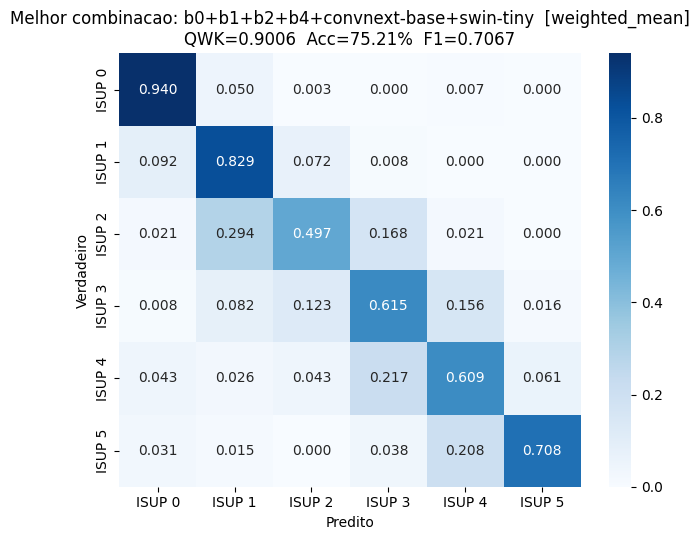

Salvo: logs/family-test-best-combination-confusion.png


In [38]:
# recupera a melhor combinacao (linha 0 do combo_df, ja ordenado por QWK)
best_combo   = combo_df.iloc[0]
best_models  = best_combo['models'].split('+')
best_strat   = best_combo['strategy']
best_idx     = [ALL_MODELS.index(n) for n in best_models]

# recalcula as predicoes da melhor combinacao com a estrategia vencedora
if best_strat == 'mean':
    best_preds = preds_from_proba(P_ALL[best_idx].mean(axis=0))
elif best_strat == 'weighted_mean':
    w = VAL_QWK_ALL[best_idx]
    w = w / w.sum()
    best_preds = preds_from_proba(np.tensordot(w, P_ALL[best_idx], axes=(0, 0)))
elif best_strat == 'median':
    best_preds = np.round(np.median(PRED_ALL[best_idx], axis=0)).astype(int)

# confere que bate com a metrica registrada em combo_df
check = eval_preds(best_preds, gts_test)
assert np.isclose(check['qwk'], best_combo['qwk']), 'predicoes recalculadas nao batem com o QWK salvo'

# matriz de confusao normalizada
cm = confusion_matrix(gts_test, best_preds, labels=list(range(6)))
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', cbar=True,
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Verdadeiro')
ax.set_title(
    f"Melhor combinacao: {best_combo['models']}  [{best_strat}]\n"
    f"QWK={best_combo['qwk']:.4f}  Acc={best_combo['accuracy']*100:.2f}%  "
    f"F1={best_combo['macro_f1']:.4f}"
)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-test-best-combination-confusion.png'),
            dpi=200, bbox_inches='tight')
plt.show()

print('Salvo: logs/family-test-best-combination-confusion.png')